In [1]:
from typing import TypedDict,List
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int 
    operation: str
    number2: int
    finalNumber: int
    number3: int
    operation2: str
    number4: int
    finalNumber2: int

In [3]:
def addition(state: AgentState) -> AgentState:
    """This function handles addition of different inputs"""
    
    state['finalNumber']= state['number1'] + state['number2']

    return state


def substraction(state: AgentState) -> AgentState:
    """This function handles substraction of different inputs"""
    
    state['finalNumber']= state['number1'] - state['number2']

    return state    


def decide_next_node(state: AgentState):
    if state['operation'] == '+':
        return 'addition_operation'    
    elif state['operation'] == '-':
        return 'substraction_operation'




def addition2(state: AgentState) -> AgentState:
    """This function handles addition of different inputs"""
    
    state['finalNumber2']= state['number3'] + state['number4']

    return state


def substraction2(state: AgentState) -> AgentState:
    """This function handles substraction of different inputs"""
    
    state['finalNumber2']= state['number3'] - state['number4']

    return state    


def decide_next_node2(state: AgentState):
    if state['operation2'] == '+':
        return 'addition_operation2'    
    elif state['operation2'] == '-':
        return 'substraction_operation2'       

In [4]:
graph = StateGraph(AgentState)

# Add nodes for Layer 1
graph.add_node('addition_operation', addition)
graph.add_node('substraction_operation', substraction)
graph.add_node('router', lambda state: state)

# Add nodes for Layer 2
graph.add_node('addition_operation2', addition2)
graph.add_node('substraction_operation2', substraction2)
graph.add_node('router2', lambda state: state)

# --- Layer 1 Logic ---
graph.add_edge(START, 'router')
graph.add_conditional_edges(
    'router',
    decide_next_node,
    {
        'addition_operation': 'addition_operation',
        'substraction_operation': 'substraction_operation'
    }
)

# Both Layer 1 operations flow into Router 2
graph.add_edge("addition_operation", 'router2')
graph.add_edge("substraction_operation", 'router2')

# --- Layer 2 Logic ---
graph.add_conditional_edges(
    'router2',
    decide_next_node2,
    {
        'addition_operation2': 'addition_operation2',
        'substraction_operatio2': 'substraction_operation2'
    }
)

# Both Layer 2 operations flow to END
graph.add_edge("addition_operation2", END)
graph.add_edge("substraction_operation2", END)
app = graph.compile()


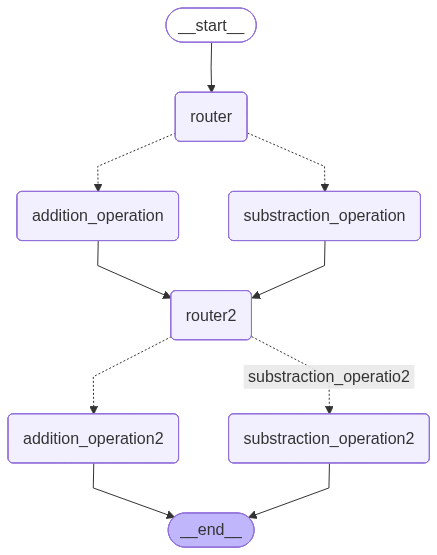

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
initial_state = AgentState(number1 = 50, operation="-", number2 = 5, number3 = 7, number4=2, operation2="+", finalNumber= 0, finalNumber2 = 0)

In [9]:
print(app.invoke(initial_state))

{'number1': 50, 'operation': '-', 'number2': 5, 'finalNumber': 45, 'number3': 7, 'operation2': '+', 'number4': 2, 'finalNumber2': 9}
